# Phase Flip Experiments

# Project 10b: Phase-Flip Error Correction

**Objective:** Correct a phase error ($Z$-gate) using the Hadamard sandwich principle.

**Theory:**
Classical bits only suffer from bit-flips (0 becomes 1). Quantum bits suffer from a second, far more insidious error: **Phase Flips**. This is a $Z$ error, where the angle of a superposition is flipped (e.g., $|+\rangle$ becomes $|-\rangle$). 

Because a $Z$-gate acts exactly like an $X$-gate when wrapped in Hadamard gates (recall from Bernstein-Vazirani that $H \cdot Z \cdot H = X$), we can use the exact same 3-qubit bit-flip code we just built. We simply wrap our error-prone communication channel in $H$ gates to convert the phase-flip into a bit-flip, catch it, correct it, and convert it back!

In [1]:
from qiskit import QuantumCircuit
from qiskit.primitives import StatevectorSampler
from qiskit.visualization import plot_histogram
from IPython.display import display

print("Environment Ready.")

Environment Ready.


## Step 1: The Hadamard Sandwich Architecture

We will prepare Qubit 0 in the $|-\rangle$ state.
We encode it just like before. 
Then, we apply $H$ gates to all qubits, inject our deadly $Z$-gate (Phase Flip), and apply $H$ gates again. This converts the phase error into a standard bit-flip error, which our Toffoli setup can easily handle.

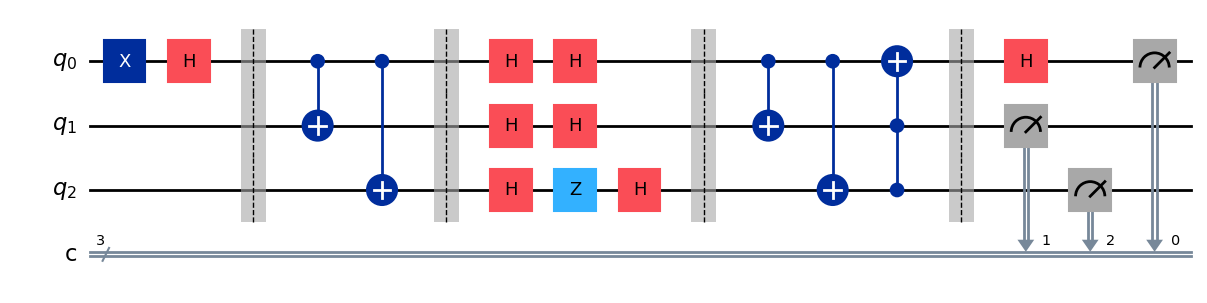

In [2]:
qc = QuantumCircuit(3, 3)

# 1. State Prep (We will protect the |-> state)
qc.x(0)
qc.h(0)
qc.barrier()

# 2. Encode
qc.cx(0, 1)
qc.cx(0, 2)
qc.barrier()

# --- PHASE FLIP PROTECTION SANDWICH ---
qc.h([0, 1, 2])

# 3. The Phase Error! (A Z-gate hits Qubit 2)
qc.z(2)

qc.h([0, 1, 2])
# --------------------------------------
qc.barrier()

# 4. Decode & Correct
qc.cx(0, 1)
qc.cx(0, 2)
qc.ccx(1, 2, 0)
qc.barrier()

# 5. Measure
# To measure if we successfully preserved the |-> state, we apply an H gate before measurement
# If the state is still |->, the H gate turns it back into a perfect |1>.
qc.h(0)
qc.measure([0,1,2], [0,1,2])

display(qc.draw('mpl'))

## Step 2: Execution

We execute the Sampler. If successful, Qubit 0 will measure as a `1` with 100% certainty, proving the $|-\rangle$ phase was protected.

Measurement Results: {'101': 1000}


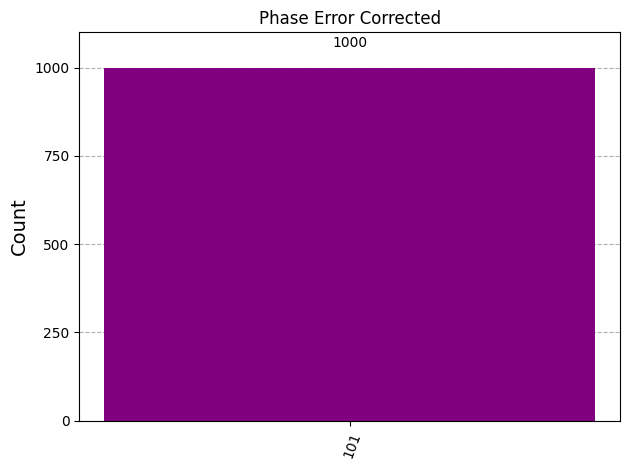

In [3]:
sampler = StatevectorSampler()
job = sampler.run([qc], shots=1000)
counts = job.result()[0].data.c.get_counts()

print(f"Measurement Results: {counts}")
display(plot_histogram(counts, title="Phase Error Corrected", color="purple"))

## Final Analysis & Repository Conclusion

**What did we observe?**
By measuring Qubit 0 as a `1` (the right-most digit in the `101` string), we proved that it safely remained in the fragile $|-\rangle$ superposition state throughout the entire execution, completely ignoring the phase-flip injected into the system.

**The Bigger Picture:**
You have just completed the foundational map of quantum computing.
- **Sprints 1 & 2** taught you entanglement and algorithmic thinking.
- **Sprint 3** gave you the QFT and mathematical translation.
- **Sprint 4** showed you how to bridge to classical computers (VQE) and how to protect fragile quantum data from the environment (Error Correction).

Combining the bit-flip and phase-flip logic together scales directly into the *Shor Code*, the baseline requirement for Fault-Tolerant Quantum Computing. 

The `quantum-toybox` repository is officially complete. (atleast till I find more toy projects and circuits to build and experiment with).